# DDSketch example

In [31]:
from matplotlib import pyplot as plt
import numpy as np

from datasketches import ddsketch_dense as ddsketch
from datasketches import tdigest_double
import seaborn as sns

In [32]:
np.random.seed(42)

stream_size = int(10e6)
plot_size = int(1e5)

### DDSketch vs t-digest: Pareto distribution

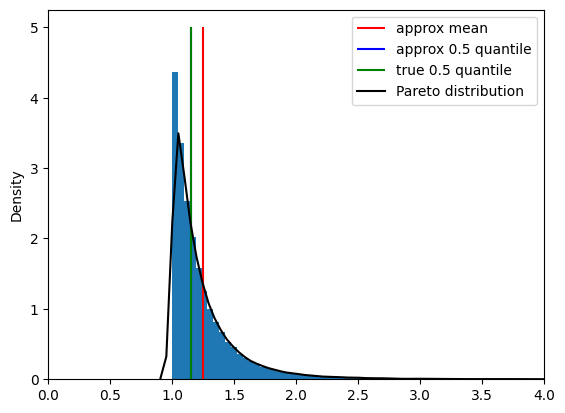

In [33]:
alpha = 1
pareto = (np.random.pareto(5, size=plot_size) + 1) * alpha

plt.hist(pareto, bins=200, density=True)
plt.vlines(np.mean(pareto), ymin=0, ymax=5, color='r', label="approx mean")
plt.vlines(np.quantile(pareto, 0.5), ymin=0, ymax=5, color='b', label="approx 0.5 quantile")
plt.vlines(np.pow(2, 1/5) , ymin=0, ymax=5, color='g', label="true 0.5 quantile")
sns.kdeplot(pareto, color="black", label="Pareto distribution")
plt.xlim((-0, 4))
plt.legend()

In [34]:
pareto = (np.random.pareto(5, size=stream_size) + 1) * alpha

In [50]:
import time 
sk = ddsketch(0.004)
t0 = time.time()
for v in pareto:
  sk.update(v)
t1 = time.time()
print((t1 - t0) / len(pareto))

1.2951602935791015e-07


In [49]:
print(time.time())

1764461028.5257127


In [36]:
print(sk.get_quantile(0.5), np.quantile(pareto, 0.5), np.pow(2, 1/5))
print(sk.get_quantile(0.25), np.quantile(pareto, 0.25))
print(str.upper("initial sketch\n"), sk)
buf = sk.serialize()
print(len(buf), sk.get_serialized_size_bytes())
deserialized_sk = ddsketch_dense.deserialize(buf)
print(str.upper("deserialized sketch\n"), deserialized_sk)
print(sk.get_quantile(0.5), deserialized_sk.get_quantile(0.5))

1.1502654555028273 1.1487099045970655 1.148698354997035
1.061828391607302 1.059234629285354
INITIAL SKETCH
 ### ddsketch summary:
   Index mapping         
      gamma             : 1.00803
      index offset      : 0
      relative accuracy : 0.004
   Min indexable value   : 2.24295e-308
   Max indexable value   : 1.79053e+308
   Positive store        
      Type              : dense store 
      Bins number       :448
      Min index         :0
      Max index         :407
   Negative store        
      Type              : dense store 
      Bins number       :0
      Min index         :2147483647
      Max index         :-2147483648
   Zero count             0
### End ddsketch summary

4097 4097
DESERIALIZED SKETCH
 ### ddsketch summary:
   Index mapping         
      gamma             : 1.00803
      index offset      : 0
      relative accuracy : 0.004
   Min indexable value   : 2.24295e-308
   Max indexable value   : 1.79053e+308
   Positive store        
      Type            

In [37]:
td = tdigest_double()
for val in pareto:
  td.update(val)

In [38]:
print(td.get_quantile(0.5), np.quantile(pareto, 0.5), np.pow(2, 1/5))
print(td.get_quantile(0.25), np.quantile(pareto, 0.25))
print(str.upper("initial sketch\n"), td)
buf = td.serialize()
print(len(buf), td.get_serialized_size_bytes())
deserialized_td = tdigest_double.deserialize(buf)
print(str.upper("deserialized sketch\n"), deserialized_td)
print(td.get_quantile(0.5), deserialized_td.get_quantile(0.5))

1.155591644446549 1.1487099045970655 1.148698354997035
1.0576318746382924 1.059234629285354
INITIAL SKETCH
 ### t-Digest summary:
   Nominal k          : 200
   Centroids          : 304
   Buffered           : 0
   Centroids capacity : 410
   Buffer capacity    : 1640
   Centroids Weight   : 10000000
   Total Weight       : 10000000
   Reverse Merge      : false
   Min                : 1
   Max                : 26.042
### End t-Digest summary

4896 4896
DESERIALIZED SKETCH
 ### t-Digest summary:
   Nominal k          : 200
   Centroids          : 304
   Buffered           : 0
   Centroids capacity : 410
   Buffer capacity    : 1640
   Centroids Weight   : 10000000
   Total Weight       : 10000000
   Reverse Merge      : false
   Min                : 1
   Max                : 26.042
### End t-Digest summary

1.155591644446549 1.155591644446549


## DDSketch vs t-digest: Gaussian distribution

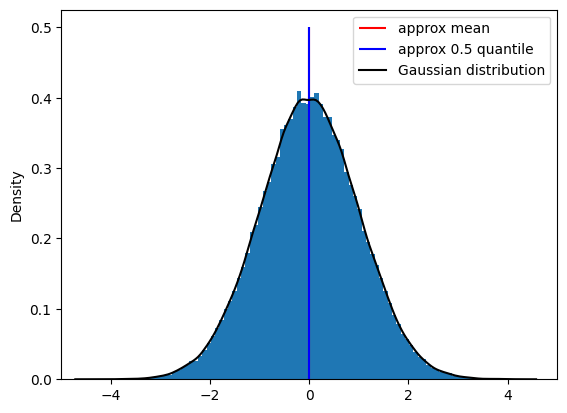

In [39]:
gaussian = np.random.normal(0, 1, size=plot_size)


plt.hist(gaussian, bins=100, density=True)
plt.vlines(np.mean(gaussian), ymin=0, ymax=0.5, color='r', label="approx mean")
plt.vlines(np.quantile(gaussian, 0.5), ymin=0, ymax=0.5, color='b', label="approx 0.5 quantile")
sns.kdeplot(gaussian, color="black", label="Gaussian distribution")
plt.xlim((-5, 5))
plt.legend()

In [40]:
gaussian = np.random.normal(0, 1, size=stream_size)

In [41]:
sk = ddsketch(0.03)
for v in gaussian:
  sk.update(v)

In [42]:
print(sk.get_quantile(0.5), np.quantile(gaussian, 0.5))
print(sk.get_quantile(0.25), np.quantile(gaussian, 0.25))
print(str.upper("initial sketch\n"), sk)
buf = sk.serialize()
print(len(buf), sk.get_serialized_size_bytes())
deserialized_sk = ddsketch.deserialize(buf)
print(str.upper("deserialized sketch\n"), deserialized_sk)
print(sk.get_quantile(0.5), deserialized_sk.get_quantile(0.5))

0.0005683958780925386 0.000582724703252875
-0.6766729121746692 -0.6745056538138668
INITIAL SKETCH
 ### ddsketch summary:
   Index mapping         
      gamma             : 1.06186
      index offset      : 0
      relative accuracy : 0.03
   Min indexable value   : 2.36271e-308
   Max indexable value   : 1.74533e+308
   Positive store        
      Type              : dense store 
      Bins number       :320
      Min index         :-272
      Max index         :27
   Negative store        
      Type              : dense store 
      Bins number       :320
      Min index         :-282
      Max index         :27
   Zero count             0
### End ddsketch summary

5978 5978
DESERIALIZED SKETCH
 ### ddsketch summary:
   Index mapping         
      gamma             : 1.06186
      index offset      : 0
      relative accuracy : 0.03
   Min indexable value   : 2.36271e-308
   Max indexable value   : 1.74533e+308
   Positive store        
      Type              : dense store 
     

In [43]:
td = tdigest_double()
for val in gaussian:
  td.update(val)

In [44]:
print(td.get_quantile(0.5), np.quantile(gaussian, 0.5))
print(td.get_quantile(0.25), np.quantile(gaussian, 0.25))
print(str.upper("initial sketch\n"), td)
buf = td.serialize()
print(len(buf), td.get_serialized_size_bytes())
deserialized_td = tdigest_double.deserialize(buf)
print(str.upper("deserialized sketch\n"), deserialized_td)
print(td.get_quantile(0.5), deserialized_td.get_quantile(0.5))

-0.035188466743692644 0.000582724703252875
-0.6790539680993843 -0.6745056538138668
INITIAL SKETCH
 ### t-Digest summary:
   Nominal k          : 200
   Centroids          : 299
   Buffered           : 0
   Centroids capacity : 410
   Buffer capacity    : 1640
   Centroids Weight   : 10000000
   Total Weight       : 10000000
   Reverse Merge      : false
   Min                : -5.30599
   Max                : 5.12867
### End t-Digest summary

4816 4816
DESERIALIZED SKETCH
 ### t-Digest summary:
   Nominal k          : 200
   Centroids          : 299
   Buffered           : 0
   Centroids capacity : 410
   Buffer capacity    : 1640
   Centroids Weight   : 10000000
   Total Weight       : 10000000
   Reverse Merge      : false
   Min                : -5.30599
   Max                : 5.12867
### End t-Digest summary

-0.035188466743692644 -0.035188466743692644
